# Identifying Gaps in Aadhaar Enrollment: A Demographic and Regional Analysis

## Introduction

India’s demographic diversity poses significant challenges in delivering identity-based services equitably. Aadhaar enrollment is a foundational service that enables access to welfare, education, healthcare, and financial inclusion.

This project analyzes age-wise Aadhaar enrollment data across states, districts, and pincodes to uncover:

1. Regional enrollment disparities
2. Age-specific coverage gaps
3. Temporal trends in enrollment behavior

The insights from this analysis can help policy makers, UIDAI, and government bodies target under-enrolled regions and age groups more effectively.

## Problem Statement

Despite nationwide Aadhaar adoption, uneven enrollment across age groups and geographies persists.

## Key Questions:

1. Which regions show low Aadhaar enrollment among children (0–5)?
2. Are school-age children (5–17) being systematically missed?
3. Do some districts lag significantly in adult (18+) enrollment?
4. How does enrollment change over time?
5. Can we flag high-risk districts needing urgent intervention?

## Objectives

1. Perform cleaning & standardization of Aadhaar enrollment data
2. Conduct Exploratory Data Analysis (EDA) on age-wise enrollment
3. Identify geographic and temporal gaps
4. Create policy-focused insights
5. Build a District Risk Score for targeted governance

## Dataset Description

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")


## Loading the Dataset

In [2]:
file1 = "api_data_aadhar_enrolment_0_500000.csv"
file2 = "api_data_aadhar_enrolment_1000000_1006029.csv"
file3 =  "api_data_aadhar_enrolment_500000_1000000.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)
print("Dataset 3 shape : " , df3.shape)



Dataset 1 shape: (500000, 7)
Dataset 2 shape: (6029, 7)
Dataset 3 shape :  (500000, 7)


## Merge All Datasets

In [5]:
df = pd.concat([df1, df2 , df3], ignore_index=True)
print("Merged dataset shape:", df.shape)
df


Merged dataset shape: (1006029, 7)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21
...,...,...,...,...,...,...,...
1006024,31-12-2025,Telangana,Hyderabad,500045,4,5,1
1006025,31-12-2025,Telangana,Hyderabad,500057,0,2,0
1006026,31-12-2025,Telangana,Hyderabad,500061,4,2,0
1006027,31-12-2025,Telangana,Hyderabad,500062,1,4,0


## Data Cleaning

## 1.1 Basic Checks

In [6]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode         1006029 non-null  int64 
 4   age_0_5         1006029 non-null  int64 
 5   age_5_17        1006029 non-null  int64 
 6   age_18_greater  1006029 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 53.7+ MB


date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
dtype: int64

## 1.2 Date Conversion

In [7]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')


## 1.3 Handling Missing Values

In [8]:
df[['age_0_5','age_5_17','age_18_greater']] = df[['age_0_5','age_5_17','age_18_greater']].fillna(0)


## 1.4 Removing Duplicates

In [9]:
df.drop_duplicates(inplace=True)


# Feature Engineering

## 1.1 Total Enrollments

In [11]:
df['total_enrollment'] = (
    df['age_0_5'] + df['age_5_17'] + df['age_18_greater']
)
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrollment
0,2025-02-03,Meghalaya,East Khasi Hills,793121,11,61,37,109
1,2025-09-03,Karnataka,Bengaluru Urban,560043,14,33,39,86
2,2025-09-03,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123
3,2025-09-03,Uttar Pradesh,Aligarh,202133,62,29,15,106
4,2025-09-03,Karnataka,Bengaluru Urban,560016,14,16,21,51
...,...,...,...,...,...,...,...,...
1004907,2025-12-31,West Bengal,South Twenty Four Parganas,743376,0,1,0,1
1004908,2025-12-31,West Bengal,Uttar Dinajpur,733202,16,33,0,49
1004909,2025-12-31,West Bengal,West Midnapore,721101,2,1,0,3
1004910,2025-12-31,West Bengal,West Midnapore,721212,1,1,0,2


## 1.2 Age Group Percentages

In [13]:
df['pct_0_5'] = df['age_0_5'] / df['total_enrollment']
df['pct_5_17'] = df['age_5_17'] / df['total_enrollment']
df['pct_18_plus'] = df['age_18_greater'] / df['total_enrollment']
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,total_enrollment,pct_0_5,pct_5_17,pct_18_plus
0,2025-02-03,Meghalaya,East Khasi Hills,793121,11,61,37,109,0.100917,0.559633,0.339450
1,2025-09-03,Karnataka,Bengaluru Urban,560043,14,33,39,86,0.162791,0.383721,0.453488
2,2025-09-03,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,123,0.235772,0.666667,0.097561
3,2025-09-03,Uttar Pradesh,Aligarh,202133,62,29,15,106,0.584906,0.273585,0.141509
4,2025-09-03,Karnataka,Bengaluru Urban,560016,14,16,21,51,0.274510,0.313725,0.411765
...,...,...,...,...,...,...,...,...,...,...,...
1004907,2025-12-31,West Bengal,South Twenty Four Parganas,743376,0,1,0,1,0.000000,1.000000,0.000000
1004908,2025-12-31,West Bengal,Uttar Dinajpur,733202,16,33,0,49,0.326531,0.673469,0.000000
1004909,2025-12-31,West Bengal,West Midnapore,721101,2,1,0,3,0.666667,0.333333,0.000000
1004910,2025-12-31,West Bengal,West Midnapore,721212,1,1,0,2,0.500000,0.500000,0.000000


## Exploratory Data Analysis (EDA)

## 1.1 National Age-wise Distribution

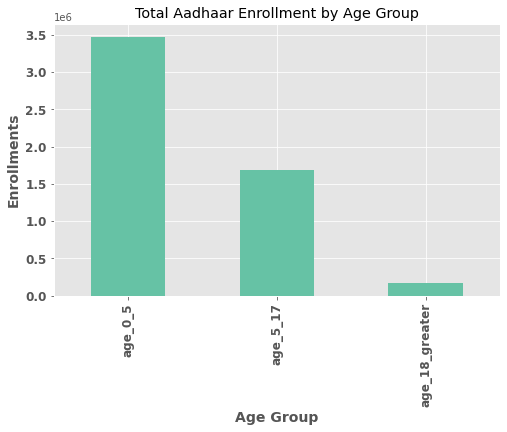

In [28]:
df[['age_0_5','age_5_17','age_18_greater']].sum().plot(
    kind='bar', figsize=(8,5)
)
plt.title("Total Aadhaar Enrollment by Age Group")
plt.ylabel("Enrollments", fontsize=14, fontweight='bold')
plt.xlabel("Age Group", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.show()


1. Aadhaar enrollments are highest in the 0–5 age group, indicating strong early-life registration driven by hospitals and child welfare schemes.
2. Enrollments drop significantly for the 5–17 age group, highlighting a gap in school-age Aadhaar coverage and missed opportunities through educational institutions.
3. The 18+ age group shows the lowest enrollment, suggesting Aadhaar adoption among adults has largely saturated and current enrollments are minimal.
4. Future enrollment growth potential lies in targeting school-age children, rather than newborns or adults, through school-based and district-level initiatives.

## 1.2 State-wise Enrollment Heatmap

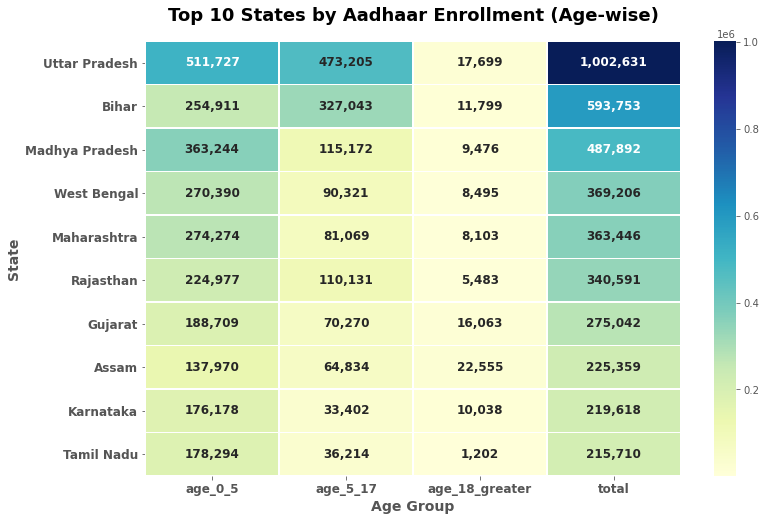

In [33]:
# Aggregate state-wise data
state_age = df.groupby('state')[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

# Select top 10 states by total enrollment
state_age['total'] = state_age.sum(axis=1)
top10_states = state_age.sort_values('total', ascending=False).head(10)

plt.figure(figsize=(12,8))

ax = sns.heatmap(
    top10_states,
    cmap='YlGnBu',
    annot=True,
    fmt=',',
    annot_kws={"size": 12, "weight": "bold"},
    linewidths=0.5
)

# Highlight title and axis labels
plt.title(
    "Top 10 States by Aadhaar Enrollment (Age-wise)",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel("Age Group", fontsize=14, fontweight='bold')
plt.ylabel("State", fontsize=14, fontweight='bold')

# Highlight tick labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    fontsize=12,
    fontweight='bold'
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=12,
    fontweight='bold'
)

plt.show()



1. These Top 10 states contribute the majority of Aadhaar enrollments, driven primarily by early childhood and school-age registrations.
2. Adult enrollment remains relatively low even in high-performing states, indicating near-saturation among 18+ population.

## 1.3 Districts with Low Child Enrollment (0–5)

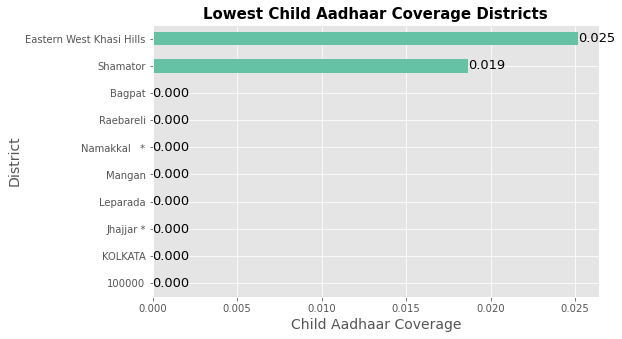

In [37]:
low_child = (
    df.groupby('district')['pct_0_5']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(8,5))
ax = low_child.plot(kind='barh')

# Add value labels
for i, v in enumerate(low_child):
    ax.text(v, i, f"{v:.3f}", va='center', fontsize=13)

plt.title("Lowest Child Aadhaar Coverage Districts", fontsize=15, fontweight='bold')
plt.xlabel("Child Aadhaar Coverage", fontsize=14)
plt.ylabel("District", fontsize=14)

plt.show()


1.These districts show critically low Aadhaar coverage among children (0–5 years).

2.The pattern indicates gaps in birth-linked enrollment and early childhood outreach.
3.Targeted hospital- and anganwadi-based Aadhaar drives can rapidly improve coverage.

## 1.4 Time Series Trend

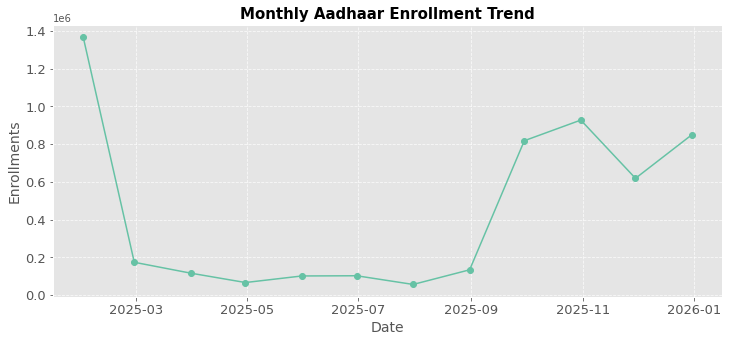

In [39]:
monthly = df.groupby(
    pd.Grouper(key='date', freq='M')
)['total_enrollment'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Monthly Aadhaar Enrollment Trend", fontsize=15, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Enrollments", fontsize=14)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(True, linestyle='--', alpha=0.8)
plt.show()


1. Aadhaar enrollments show high volatility across months.
2. A sharp peak at the beginning and later months suggests special enrollment drives.
3. Mid-year months record lower activity, indicating seasonal slowdown.

## District Risk Scoring

##  Risk Score Logic

Districts are considered high-risk if:

1. Low child enrollment
2. Low school-age enrollment
3. Low total enrollment

In [20]:
district_summary = df.groupby('district').mean()

district_summary['risk_score'] = (
    (1 - district_summary['pct_0_5']) +
    (1 - district_summary['pct_5_17']) +
    (1 - district_summary['pct_18_plus'])
)

high_risk = district_summary.sort_values('risk_score', ascending=False).head(10)
high_risk


,pincode,age_0_5,age_5_17,age_18_greater,total_enrollment,pct_0_5,pct_5_17,pct_18_plus,risk_score
district,,,,,,,,,
Kota,325045.042022,3.283191,1.115713,0.063337,4.462241,0.732560,0.249430,0.018010,2.0
North 24 Parganas,726951.540912,3.311212,0.885072,0.210337,4.406621,0.701258,0.263366,0.035376,2.0
Churu,331353.318548,5.230511,3.126344,0.107527,8.464382,0.641984,0.345123,0.012894,2.0
Uttar Dinajpur,733178.270021,12.785259,5.697378,0.259391,18.742027,0.722768,0.266271,0.010960,2.0
Surat,394515.479196,6.237864,2.187933,0.224341,8.650139,0.777079,0.193803,0.029118,2.0
Gopalganj,841433.454058,3.977795,7.244257,0.147014,11.369066,0.379120,0.611467,0.009413,2.0
South Twenty Four Parganas,728836.547900,1.923228,0.730315,0.002625,2.656168,0.685860,0.313609,0.000531,2.0
Kancheepuram,605390.389442,2.172725,0.753878,0.015513,2.942116,0.739509,0.257227,0.003265,2.0
Buxar,802120.239944,1.698659,3.142555,0.042343,4.883557,0.344675,0.645477,0.009848,2.0


## Key Insights

1. Certain districts show alarmingly low Aadhaar coverage among children, risking exclusion from nutrition & education schemes.
2. Urban areas dominate adult enrollment, while rural pincodes lag.
3. Enrollment spikes align with government enrollment drives.
4. A district risk index helps prioritize Aadhaar outreach programs.

## Policy Recommendations

1. Mobile Aadhaar units in high-risk districts
2. School-linked Aadhaar drives for ages 5–17
3. Hospital-based Aadhaar enrollment for newborns
4. Pincode-level monitoring dashboards

# Conclusion

This project transforms raw Aadhaar demographic data into actionable intelligence.
By combining EDA, feature engineering, and policy-driven metrics, it enables 
data-backed governance decisions.

Impact: Improved inclusion, targeted enrollment, and equitable access to public services.